# 12 Classical Metrics for LaMa Restoration

This notebook evaluates the LaMa pretrained inpainting baseline using the same classical full-reference metrics previously applied to the OpenCV Telea baseline.

The metrics compare:

- clean reference vs damaged input,
- clean reference vs LaMa restored output.

Metrics:

- MSE,
- MAE,
- PSNR,
- SSIM.

Evaluation regions:

- full image,
- content region,
- masked region,
- mask bounding-box crop.

This notebook does not compare LaMa against OpenCV directly yet. It first generates the LaMa-only classical metric outputs in the same structure as the OpenCV baseline.

In [28]:
from pathlib import Path
import sys
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Source directory exists:", SRC_DIR.exists())
print("Config path:", CONFIG_PATH)
print("Config exists:", CONFIG_PATH.exists())

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Source directory not found: {SRC_DIR}")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Experiment config not found: {CONFIG_PATH}")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Source directory exists: True
Config path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml
Config exists: True


In [29]:
import pandas as pd
import numpy as np
from pathlib import Path

from restoration_eval.metrics_classical import (
    compute_classical_metrics_for_restorations,
    validate_classical_metrics,
    summarize_classical_metrics,
)

with CONFIG_PATH.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths_cfg = config.get("paths", {})
preprocessing_cfg = config.get("preprocessing", {})

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
metrics_dir.mkdir(parents=True, exist_ok=True)

lama_metadata_path = processed_metadata_dir / "metadata_restored_lama.csv"

classical_metrics_path = metrics_dir / "classical_metrics_lama_50.csv"
summary_by_mask_type_path = metrics_dir / "classical_metrics_summary_by_mask_type_lama_50.csv"
summary_by_category_path = metrics_dir / "classical_metrics_summary_by_category_lama_50.csv"
summary_by_region_path = metrics_dir / "classical_metrics_summary_by_region_lama_50.csv"
summary_by_region_mask_type_path = metrics_dir / "classical_metrics_summary_by_region_mask_type_lama_50.csv"
masked_region_summary_path = metrics_dir / "classical_metrics_masked_region_summary_lama_50.csv"
strongest_cases_path = metrics_dir / "lama_strongest_masked_region_cases_50.csv"
weakest_cases_path = metrics_dir / "lama_weakest_masked_region_cases_50.csv"

target_size = (
    preprocessing_cfg.get("output_size")
    or preprocessing_cfg.get("target_size")
    or config.get("experiment", {}).get("image_size")
    or 768
)

model_name = "lama"

print("LaMa restoration metadata:", lama_metadata_path)
print("Exists:", lama_metadata_path.exists())
print("Metrics output:", classical_metrics_path)
print("Target size:", target_size)
print("Model name:", model_name)

if not lama_metadata_path.exists():
    raise FileNotFoundError(
        f"LaMa restoration metadata not found: {lama_metadata_path}. "
        "Run Notebook 11 first."
    )

LaMa restoration metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_lama.csv
Exists: True
Metrics output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_lama_50.csv
Target size: 768
Model name: lama


In [30]:
lama_restored_df = pd.read_csv(lama_metadata_path)

print("LaMa restored metadata shape:", lama_restored_df.shape)
display(lama_restored_df.head())

print("\nColumns:")
print(list(lama_restored_df.columns))

print("\nStatus counts:")
display(lama_restored_df["status"].value_counts(dropna=False))

print("\nInference mode counts:")
display(lama_restored_df["inference_mode"].value_counts(dropna=False))

print("\nMask type counts:")
display(lama_restored_df["mask_type"].value_counts().sort_index())

LaMa restored metadata shape: (250, 32)


,case_id,painting_id,mask_id,mask_type,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,...,model_name,restoration_method,inference_mode,restored_filename,restored_path,device,batch_runtime_seconds,restored_width,restored_height,restored_mode
0,p001_loss_large,p001,p001_loss_large,loss_large,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,iopaint_lama,model_inference,p001_loss_large_restored_lama.png,data/processed/restored/lama/p001_loss_large_r...,cuda,302.614275,768,768,RGB
1,p001_loss_small,p001,p001_loss_small,loss_small,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,iopaint_lama,model_inference,p001_loss_small_restored_lama.png,data/processed/restored/lama/p001_loss_small_r...,cuda,302.614275,768,768,RGB
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,iopaint_lama,model_inference,p001_mixed_damage_restored_lama.png,data/processed/restored/lama/p001_mixed_damage...,cuda,302.614275,768,768,RGB
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,iopaint_lama,model_inference,p001_scratch_thin_restored_lama.png,data/processed/restored/lama/p001_scratch_thin...,cuda,302.614275,768,768,RGB
4,p001_zero_control,p001,p001_zero_control,zero_control,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,lama,zero_control_copy,copied_zero_control,p001_zero_control_restored_lama.png,data/processed/restored/lama/p001_zero_control...,none,0.000000,768,768,RGB



Columns:
['case_id', 'painting_id', 'mask_id', 'mask_type', 'clean_filename', 'clean_path', 'mask_filename', 'mask_path', 'damaged_filename', 'damaged_path', 'damage_fill_strategy', 'damage_fill_r', 'damage_fill_g', 'damage_fill_b', 'damaged_area_pixels', 'damaged_area_percentage_content', 'damaged_area_percentage_full', 'status', 'issue', 'lama_staged_input_path', 'lama_staged_mask_path', 'lama_staged_output_path', 'model_name', 'restoration_method', 'inference_mode', 'restored_filename', 'restored_path', 'device', 'batch_runtime_seconds', 'restored_width', 'restored_height', 'restored_mode']

Status counts:


status
ok    250
Name: count, dtype: int64


Inference mode counts:


inference_mode
model_inference        200
copied_zero_control     50
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64

In [31]:
processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

if not processed_clean_metadata_path.exists():
    raise FileNotFoundError(
        f"Processed clean metadata not found: {processed_clean_metadata_path}"
    )

processed_clean_df = pd.read_csv(processed_clean_metadata_path)

needed_processed_columns = [
    "painting_id",
    "category",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_processed_columns = [
    column for column in needed_processed_columns
    if column not in processed_clean_df.columns
]

if missing_processed_columns:
    raise ValueError(
        f"Processed clean metadata missing required columns: {missing_processed_columns}"
    )

metadata_lookup_df = (
    processed_clean_df[needed_processed_columns]
    .drop_duplicates(subset=["painting_id"])
    .copy()
)

if metadata_lookup_df["category"].isna().any():
    raise ValueError("Processed clean metadata contains missing category labels.")

lama_restored_enriched_df = lama_restored_df.copy()

# Remove stale/broken versions before merging.
columns_to_replace = [
    "category",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

lama_restored_enriched_df = lama_restored_enriched_df.drop(
    columns=[col for col in columns_to_replace if col in lama_restored_enriched_df.columns],
    errors="ignore",
)

lama_restored_enriched_df = lama_restored_enriched_df.merge(
    metadata_lookup_df,
    on="painting_id",
    how="left",
)

required_after_merge = [
    "category",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_after_merge = (
    lama_restored_enriched_df[required_after_merge]
    .isna()
    .sum()
)

print("Missing values after enrichment:")
display(missing_after_merge)

if missing_after_merge.sum() != 0:
    display(
        lama_restored_enriched_df[
            lama_restored_enriched_df[required_after_merge].isna().any(axis=1)
        ].head(20)
    )
    raise ValueError("LaMa metadata enrichment failed.")

print("Enriched LaMa metadata shape:", lama_restored_enriched_df.shape)

print("\nCategory counts by painting:")
display(
    lama_restored_enriched_df[["painting_id", "category"]]
    .drop_duplicates()
    ["category"]
    .value_counts()
    .sort_index()
)

print("\nCategory counts by restoration rows:")
display(
    lama_restored_enriched_df["category"]
    .value_counts()
    .sort_index()
)

display(
    lama_restored_enriched_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "content_x_min",
            "content_y_min",
            "content_x_max",
            "content_y_max",
        ]
    ].head()
)

print("LaMa metadata enrichment passed.")

Missing values after enrichment:


category         0
content_x_min    0
content_y_min    0
content_x_max    0
content_y_max    0
dtype: int64

Enriched LaMa metadata shape: (250, 37)

Category counts by painting:


category
abstraction_surrealism     10
architecture_structured    10
high_texture_brushwork     10
landscape_natural          10
portrait_figure            10
Name: count, dtype: int64


Category counts by restoration rows:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64

,case_id,painting_id,category,mask_type,content_x_min,content_y_min,content_x_max,content_y_max
0,p001_loss_large,p001,portrait_figure,loss_large,52,0,715,768
1,p001_loss_small,p001,portrait_figure,loss_small,52,0,715,768
2,p001_mixed_damage,p001,portrait_figure,mixed_damage,52,0,715,768
3,p001_scratch_thin,p001,portrait_figure,scratch_thin,52,0,715,768
4,p001_zero_control,p001,portrait_figure,zero_control,52,0,715,768


LaMa metadata enrichment passed.


In [32]:
required_columns = [
    "case_id",
    "painting_id",
    "category",
    "mask_id",
    "mask_type",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
    "model_name",
    "status",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_columns = [
    column for column in required_columns
    if column not in lama_restored_enriched_df.columns
]

if missing_columns:
    raise ValueError(f"Enriched LaMa metadata missing required columns: {missing_columns}")

if len(lama_restored_enriched_df) != 250:
    raise ValueError(
        f"Expected 250 LaMa metadata rows, found {len(lama_restored_enriched_df)}."
    )

if lama_restored_enriched_df["case_id"].duplicated().any():
    duplicate_cases = lama_restored_enriched_df.loc[
        lama_restored_enriched_df["case_id"].duplicated(),
        "case_id",
    ].tolist()
    raise ValueError(f"Duplicate case IDs found: {duplicate_cases[:10]}")

if (lama_restored_enriched_df["status"] != "ok").any():
    display(lama_restored_enriched_df[lama_restored_enriched_df["status"] != "ok"])
    raise ValueError("LaMa metadata contains non-ok rows.")

if set(lama_restored_enriched_df["model_name"].unique()) != {model_name}:
    raise ValueError(
        f"Unexpected model names: {lama_restored_enriched_df['model_name'].unique()}"
    )

expected_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_mask_counts = lama_restored_enriched_df["mask_type"].value_counts().to_dict()

print("Expected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 50,
    "landscape_natural": 50,
    "architecture_structured": 50,
    "abstraction_surrealism": 50,
    "high_texture_brushwork": 50,
}

actual_category_counts = lama_restored_enriched_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

print("Enriched LaMa metadata gates passed.")

Expected mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Expected category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}
Actual category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}
Enriched LaMa metadata gates passed.


In [33]:
lama_metrics_input_df = lama_restored_enriched_df.copy()

for path_column in ["clean_path", "damaged_path", "mask_path", "restored_path"]:
    lama_metrics_input_df[path_column] = lama_metrics_input_df[path_column].apply(
        lambda value: str(PROJECT_ROOT / value) if not Path(value).is_absolute() else value
    )

classical_metrics_df = compute_classical_metrics_for_restorations(
    lama_metrics_input_df,
    target_size=target_size,
    mask_bbox_margin=8,
    progress_every=25,
)

print("Classical metrics shape:", classical_metrics_df.shape)
display(classical_metrics_df.head())

print("\nRegion counts:")
display(classical_metrics_df["evaluation_region"].value_counts())

print("\nMask type counts:")
display(classical_metrics_df["mask_type"].value_counts().sort_index())

print("\nCategory counts:")
display(classical_metrics_df["category"].value_counts().sort_index())

print("\nModel names:")
display(classical_metrics_df["model_name"].value_counts(dropna=False))

print("\nStatus counts:")
display(classical_metrics_df["status"].value_counts(dropna=False))

if (classical_metrics_df["status"] != "ok").any():
    display(classical_metrics_df[classical_metrics_df["status"] != "ok"])
    raise ValueError("Some classical metric rows failed.")

print("LaMa classical metrics computed successfully.")

Starting classical metric computation
  Cases: 250
  Target size: 768
  Mask bbox margin: 8
  Expected metric rows: 900 for the full 50-painting experiment
Computing classical metrics for case 1/250 (p001_loss_large) | elapsed 0.00s
Computing classical metrics for case 25/250 (p005_zero_control) | elapsed 59.31s
Computing classical metrics for case 50/250 (p010_zero_control) | elapsed 119.72s
Computing classical metrics for case 75/250 (p015_zero_control) | elapsed 176.28s
Computing classical metrics for case 100/250 (p020_zero_control) | elapsed 234.77s
Computing classical metrics for case 125/250 (p025_zero_control) | elapsed 294.35s
Computing classical metrics for case 150/250 (p030_zero_control) | elapsed 353.48s
Computing classical metrics for case 175/250 (p035_zero_control) | elapsed 416.77s
Computing classical metrics for case 200/250 (p040_zero_control) | elapsed 485.61s
Computing classical metrics for case 225/250 (p045_zero_control) | elapsed 548.73s
Computing classical metr

,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,restored_mae,mae_improvement,damaged_psnr,restored_psnr,psnr_improvement,damaged_ssim,restored_ssim,ssim_improvement,status,issue
0,p001_loss_large,p001,portrait_figure,,p001_loss_large,loss_large,lama,full_image,589824,0.0,...,1.115925,23.942573,10.659855,32.875594,22.215739,0.897178,0.964656,0.067478,ok,
1,p001_loss_large,p001,portrait_figure,,p001_loss_large,loss_large,lama,content_region,509184,52.0,...,1.292655,27.734383,10.021378,32.237118,22.215741,0.880745,0.959007,0.078262,ok,
2,p001_loss_large,p001,portrait_figure,,p001_loss_large,loss_large,lama,masked_region,67242,NaN,...,9.788515,210.016127,1.229037,23.444778,22.215740,NaN,NaN,NaN,ok,
3,p001_loss_large,p001,portrait_figure,,p001_loss_large,loss_large,lama,mask_bbox_crop,126750,221.0,...,5.192894,111.415398,3.982111,26.197851,22.215739,0.512661,0.832482,0.319821,ok,
4,p001_loss_small,p001,portrait_figure,,p001_loss_small,loss_small,lama,full_image,589824,0.0,...,0.118530,8.745892,15.279670,50.136523,34.856853,0.953800,0.994027,0.040227,ok,



Region counts:


evaluation_region
full_image        250
content_region    250
masked_region     200
mask_bbox_crop    200
Name: count, dtype: int64


Mask type counts:


...


Model names:


model_name
lama    900
Name: count, dtype: int64


Status counts:


status
ok    900
Name: count, dtype: int64

LaMa classical metrics computed successfully.


In [34]:
# print("Classical metrics shape:", classical_metrics_df.shape)
# display(classical_metrics_df.head())

# print("\nRegion counts:")
# display(classical_metrics_df["evaluation_region"].value_counts())

# print("\nMask type counts:")
# display(classical_metrics_df["mask_type"].value_counts().sort_index())

# print("\nModel names:")
# display(classical_metrics_df["model_name"].value_counts(dropna=False))

# print("\nStatus counts:")
# display(classical_metrics_df["status"].value_counts(dropna=False))

# if (classical_metrics_df["status"] != "ok").any():
#     display(classical_metrics_df[classical_metrics_df["status"] != "ok"])
#     raise ValueError("Some classical metric rows failed.")

# print("LaMa classical metrics computed successfully.")

In [35]:
classical_validation_df = validate_classical_metrics(
    classical_metrics_df,
    expected_rows=900,
)

print("Classical metrics validation:")
display(classical_validation_df)

if not classical_validation_df["passed"].all():
    raise ValueError("LaMa classical metrics validation failed.")

print("LaMa classical metrics validation passed.")

Classical metrics validation:


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 900, found 900."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 250, 'content_region': 250, 'ma..."


LaMa classical metrics validation passed.


In [36]:
classical_metrics_df.to_csv(classical_metrics_path, index=False)

print("Saved LaMa classical metrics:")
print(classical_metrics_path)

saved_metrics_df = pd.read_csv(classical_metrics_path)

print("Saved shape:", saved_metrics_df.shape)

if len(saved_metrics_df) != len(classical_metrics_df):
    raise ValueError(
        f"Saved metrics row count mismatch: "
        f"expected {len(classical_metrics_df)}, found {len(saved_metrics_df)}."
    )

if len(saved_metrics_df) != 900:
    raise ValueError(f"Expected 900 saved metric rows, found {len(saved_metrics_df)}.")

if (saved_metrics_df["status"] != "ok").any():
    display(saved_metrics_df[saved_metrics_df["status"] != "ok"])
    raise ValueError("Saved LaMa classical metrics contain non-ok rows.")

print("Full LaMa classical metrics saved successfully.")

Saved LaMa classical metrics:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_lama_50.csv
Saved shape: (900, 30)
Full LaMa classical metrics saved successfully.


In [37]:
summary_by_mask_type_df = summarize_classical_metrics(
    classical_metrics_df,
    group_columns=["mask_type"],
)

summary_by_category_df = summarize_classical_metrics(
    classical_metrics_df,
    group_columns=["category"],
)

summary_by_region_df = summarize_classical_metrics(
    classical_metrics_df,
    group_columns=["evaluation_region"],
)

summary_by_region_mask_type_df = summarize_classical_metrics(
    classical_metrics_df,
    group_columns=["evaluation_region", "mask_type"],
)

masked_region_summary_df = summarize_classical_metrics(
    classical_metrics_df[classical_metrics_df["evaluation_region"] == "masked_region"],
    group_columns=["mask_type"],
)

print("Summary by mask type:")
display(summary_by_mask_type_df)

print("\nSummary by category:")
display(summary_by_category_df)

print("\nSummary by evaluation region:")
display(summary_by_region_df)

print("\nSummary by region and mask type:")
display(summary_by_region_mask_type_df)

print("\nMasked-region summary by mask type:")
display(masked_region_summary_df)

Summary by mask type:


,mask_type,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,loss_large,200,50,11323.9828,449.4900,10874.4927,65.5425,8.6594,56.8832,10.0675,25.2258,15.1583,0.8031,0.8668,0.0637,304707.235
1,loss_small,200,50,7656.2517,107.4293,7548.8224,43.9286,3.1965,40.7320,14.2766,34.4440,20.1674,0.9478,0.9789,0.0311,334144.560
2,mixed_damage,200,50,8715.1308,182.1710,8532.9597,49.2290,4.4432,44.7858,12.0471,29.6298,17.5828,0.8917,0.9582,0.0665,384264.205
3,scratch_thin,200,50,7605.5491,68.1569,7537.3922,41.6982,2.4185,39.2796,16.8189,38.0604,21.2415,0.9411,0.9928,0.0517,373697.085
4,zero_control,100,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,522240.000



Summary by category:


,category,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,abstraction_surrealism,180,50,5931.7555,312.0993,5619.6563,36.4359,5.1548,31.2811,14.7821,30.5862,15.8041,0.9203,0.9585,0.0382,392566.9000
1,architecture_structured,180,50,7612.3012,125.5851,7486.7161,44.7338,3.8143,40.9195,13.1676,32.0160,18.8484,0.9090,0.9551,0.0461,357633.6389
2,high_texture_brushwork,180,50,7923.2860,152.2196,7771.0664,46.0922,4.1256,41.9666,12.8508,31.8345,18.9837,0.9098,0.9529,0.0431,371109.8500
3,landscape_natural,180,50,6464.3338,175.6318,6288.7020,39.8556,4.3868,35.4688,14.3116,30.9794,16.6679,0.9124,0.9510,0.0387,350709.4500
4,portrait_figure,180,50,11291.5616,131.4056,11160.1560,55.5473,3.3160,52.2313,11.4005,33.7838,22.3834,0.9026,0.9646,0.0620,370128.0333



Summary by evaluation region:


,evaluation_region,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,content_region,250,250,1572.5250,42.1763,1530.3487,8.9654,0.9172,8.0482,16.6442,35.1816,18.5375,0.9367,0.9731,0.0365,454656.000
1,full_image,250,250,1203.4601,33.5904,1169.8697,6.8572,0.7117,6.1455,17.8125,36.3499,18.5375,0.9506,0.9791,0.0286,589824.000
2,mask_bbox_crop,200,200,4835.2005,156.7296,4678.4709,27.8695,3.2629,24.6067,14.4229,32.9604,18.5375,0.8288,0.9072,0.0784,318789.815
3,masked_region,200,200,26995.7325,555.8093,26439.9232,152.7505,13.4187,139.3318,4.3305,22.8680,18.5375,NaN,NaN,NaN,33543.270



Summary by region and mask type:


,evaluation_region,mask_type,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,content_region,loss_large,50,50,3298.9742,131.9880,3166.9863,19.0271,2.5025,16.5246,13.5845,28.7428,15.1583,0.9031,0.9348,0.0317,454656.00
1,content_region,loss_small,50,50,1185.8752,16.0174,1169.8578,6.7963,0.4837,6.3126,17.9830,38.1504,20.1674,0.9555,0.9823,0.0268,454656.00
2,content_region,mixed_damage,50,50,2744.7069,57.3847,2687.3222,15.5419,1.4038,14.1381,14.2714,31.8542,17.5828,0.8852,0.9556,0.0703,454656.00
3,content_region,scratch_thin,50,50,633.0685,5.4914,627.5771,3.4620,0.1961,3.2659,20.7378,41.9792,21.2415,0.9395,0.9930,0.0535,454656.00
4,content_region,zero_control,50,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,454656.00
5,full_image,loss_large,50,50,2550.7766,107.6721,2443.1045,14.7026,1.9745,12.7281,14.7528,29.9111,15.1583,0.9253,0.9496,0.0243,589824.00
6,full_image,loss_small,50,50,901.8392,12.3683,889.4710,5.1609,0.3693,4.7916,19.1513,39.3187,20.1674,0.9662,0.9866,0.0203,589824.00
7,full_image,mixed_damage,50,50,2083.1693,43.7791,2039.3903,11.7803,1.0647,10.7156,15.4397,33.0225,17.5828,0.9105,0.9657,0.0553,589824.00
8,full_image,scratch_thin,50,50,481.5154,4.1326,477.3828,2.6420,0.1498,2.4922,21.9061,43.1475,21.2415,0.9510,0.9938,0.0429,589824.00
9,full_image,zero_control,50,50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,589824.00



Masked-region summary by mask type:


,mask_type,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,loss_large,50,50,25580.7229,1025.3471,24555.3758,148.1165,19.6230,128.4935,4.5927,19.7509,15.1583,NaN,NaN,NaN,58769.48
1,loss_small,50,50,26519.8804,372.1267,26147.7537,152.0709,11.0655,141.0054,4.3729,24.5403,20.1674,NaN,NaN,NaN,19951.84
2,mixed_damage,50,50,27237.5939,568.5042,26669.0898,153.7445,13.8625,139.8820,4.2923,21.8751,17.5828,NaN,NaN,NaN,45450.92
3,scratch_thin,50,50,28644.7328,257.2593,28387.4735,157.0701,9.1239,147.9462,4.0641,25.3056,21.2415,NaN,NaN,NaN,10000.84


In [38]:
# Fix missing category labels in classical_metrics_df.
# Metric values are already correct; only metadata labels need enrichment.

processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

if not processed_clean_metadata_path.exists():
    raise FileNotFoundError(
        f"Processed clean metadata not found: {processed_clean_metadata_path}"
    )

processed_clean_df = pd.read_csv(processed_clean_metadata_path)

category_lookup_columns = ["painting_id", "category"]

missing_lookup_columns = [
    column for column in category_lookup_columns
    if column not in processed_clean_df.columns
]

if missing_lookup_columns:
    raise ValueError(
        f"Processed clean metadata missing lookup columns: {missing_lookup_columns}"
    )

category_lookup_df = (
    processed_clean_df[category_lookup_columns]
    .drop_duplicates()
    .copy()
)

print("Category lookup:")
display(category_lookup_df["category"].value_counts().sort_index())

# Drop existing broken/blank category column before merging clean category labels.
classical_metrics_df = classical_metrics_df.drop(
    columns=["category"],
    errors="ignore",
)

classical_metrics_df = classical_metrics_df.merge(
    category_lookup_df,
    on="painting_id",
    how="left",
)

missing_category_rows = classical_metrics_df["category"].isna().sum()

print("Missing category rows after merge:", missing_category_rows)

if missing_category_rows != 0:
    display(classical_metrics_df[classical_metrics_df["category"].isna()].head(20))
    raise ValueError("Some metric rows still have missing category labels.")

print("Classical metrics category counts:")
display(
    classical_metrics_df[["painting_id", "category"]]
    .drop_duplicates()
    ["category"]
    .value_counts()
    .sort_index()
)

print("Category enrichment fixed.")

Category lookup:


category
abstraction_surrealism     10
architecture_structured    10
high_texture_brushwork     10
landscape_natural          10
portrait_figure            10
Name: count, dtype: int64

Missing category rows after merge: 0
Classical metrics category counts:


category
abstraction_surrealism     10
architecture_structured    10
high_texture_brushwork     10
landscape_natural          10
portrait_figure            10
Name: count, dtype: int64

Category enrichment fixed.


In [39]:
summary_by_mask_type_df.to_csv(summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(summary_by_category_path, index=False)
summary_by_region_df.to_csv(summary_by_region_path, index=False)
summary_by_region_mask_type_df.to_csv(summary_by_region_mask_type_path, index=False)
masked_region_summary_df.to_csv(masked_region_summary_path, index=False)

print("Saved summary by mask type:")
print(summary_by_mask_type_path)

print("\nSaved summary by category:")
print(summary_by_category_path)

print("\nSaved summary by region:")
print(summary_by_region_path)

print("\nSaved summary by region and mask type:")
print(summary_by_region_mask_type_path)

print("\nSaved masked-region summary:")
print(masked_region_summary_path)

for output_path in [
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    masked_region_summary_path,
]:
    if not output_path.exists():
        raise FileNotFoundError(f"Expected output file missing: {output_path}")

print("\nAll LaMa classical summary files saved.")

Saved summary by mask type:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_mask_type_lama_50.csv

Saved summary by category:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_category_lama_50.csv

Saved summary by region:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_region_lama_50.csv

Saved summary by region and mask type:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_summary_by_region_mask_type_lama_50.csv

Saved masked-region summary:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_masked_region_summary_lama_50.csv

All LaMa classical summary files saved.


In [40]:
masked_region_metrics_df = classical_metrics_df[
    (classical_metrics_df["evaluation_region"] == "masked_region")
    & (classical_metrics_df["status"] == "ok")
].copy()

if len(masked_region_metrics_df) != 200:
    raise ValueError(
        f"Expected 200 masked-region metric rows, found {len(masked_region_metrics_df)}."
    )

strongest_masked_region_cases_df = (
    masked_region_metrics_df
    .sort_values("mse_improvement", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

weakest_masked_region_cases_df = (
    masked_region_metrics_df
    .sort_values("mse_improvement", ascending=True)
    .head(20)
    .reset_index(drop=True)
)

print("Strongest LaMa masked-region MSE improvement cases:")
display(
    strongest_masked_region_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_mae",
            "restored_mae",
            "mae_improvement",
        ]
    ]
)

print("\nWeakest LaMa masked-region MSE improvement cases:")
display(
    weakest_masked_region_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_mae",
            "restored_mae",
            "mae_improvement",
        ]
    ]
)

Strongest LaMa masked-region MSE improvement cases:


,case_id,painting_id,category,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_mae,restored_mae,mae_improvement
0,p006_loss_large,p006,portrait_figure,loss_large,52182.812500,143.131882,52039.680618,227.927612,6.756586,221.171026
1,p006_mixed_damage,p006,portrait_figure,mixed_damage,51966.468750,28.328691,51938.140059,227.115173,3.134551,223.980622
2,p002_loss_large,p002,portrait_figure,loss_large,51229.851562,94.772537,51135.079025,225.618668,6.456553,219.162114
3,p006_scratch_thin,p006,portrait_figure,scratch_thin,51070.074219,32.097549,51037.976669,224.160110,2.823565,221.336545
4,p001_mixed_damage,p001,portrait_figure,mixed_damage,50740.699219,296.203278,50444.495941,224.467377,8.570448,215.896929
5,p002_scratch_thin,p002,portrait_figure,scratch_thin,50183.656250,20.065552,50163.590698,222.061203,2.431919,219.629284
6,p006_loss_small,p006,portrait_figure,loss_small,49847.976562,9.905508,49838.071054,222.692871,2.113815,220.579056
7,p001_loss_large,p001,portrait_figure,loss_large,48997.804688,294.172852,48703.631836,219.804642,9.788515,210.016127
8,p001_scratch_thin,p001,portrait_figure,scratch_thin,48508.554688,144.879562,48363.675125,217.938049,6.475495,211.462554
9,p001_loss_small,p001,portrait_figure,loss_small,46995.500000,15.359286,46980.140714,216.069458,2.889164,213.180294



Weakest LaMa masked-region MSE improvement cases:


,case_id,painting_id,category,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_mae,restored_mae,mae_improvement
0,p036_loss_large,p036,abstraction_surrealism,loss_large,5263.032715,3578.788330,1684.244385,46.358219,22.574953,23.783266
1,p036_scratch_thin,p036,abstraction_surrealism,scratch_thin,2009.945190,23.089705,1986.855486,29.343353,2.382572,26.960781
2,p032_mixed_damage,p032,abstraction_surrealism,mixed_damage,2763.684326,29.557987,2734.126339,40.720081,3.702726,37.017356
3,p036_loss_small,p036,abstraction_surrealism,loss_small,3290.943359,7.804710,3283.138649,37.022774,2.061234,34.961540
4,p020_loss_small,p020,landscape_natural,loss_small,4237.945801,255.874619,3982.071182,62.286888,8.786749,53.500139
5,p036_mixed_damage,p036,abstraction_surrealism,mixed_damage,4701.547852,641.123535,4060.424316,42.428127,5.871369,36.556758
6,p020_mixed_damage,p020,landscape_natural,mixed_damage,4976.781738,357.963684,4618.818054,62.755474,10.060729,52.694745
7,p020_loss_large,p020,landscape_natural,loss_large,6440.327148,1232.779663,5207.547485,72.366478,26.041857,46.324621
8,p042_loss_large,p042,high_texture_brushwork,loss_large,5220.112793,9.283466,5210.829327,70.196960,2.365676,67.831285
9,p032_scratch_thin,p032,abstraction_surrealism,scratch_thin,5889.045898,81.826447,5807.219452,56.945431,5.123652,51.821779


In [41]:
strongest_masked_region_cases_df.to_csv(strongest_cases_path, index=False)
weakest_masked_region_cases_df.to_csv(weakest_cases_path, index=False)

print("Saved strongest masked-region cases:")
print(strongest_cases_path)

print("\nSaved weakest masked-region cases:")
print(weakest_cases_path)

for output_path in [strongest_cases_path, weakest_cases_path]:
    if not output_path.exists():
        raise FileNotFoundError(f"Expected output file missing: {output_path}")

print("\nStrongest/weakest LaMa case tables saved.")

Saved strongest masked-region cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lama_strongest_masked_region_cases_50.csv

Saved weakest masked-region cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lama_weakest_masked_region_cases_50.csv

Strongest/weakest LaMa case tables saved.


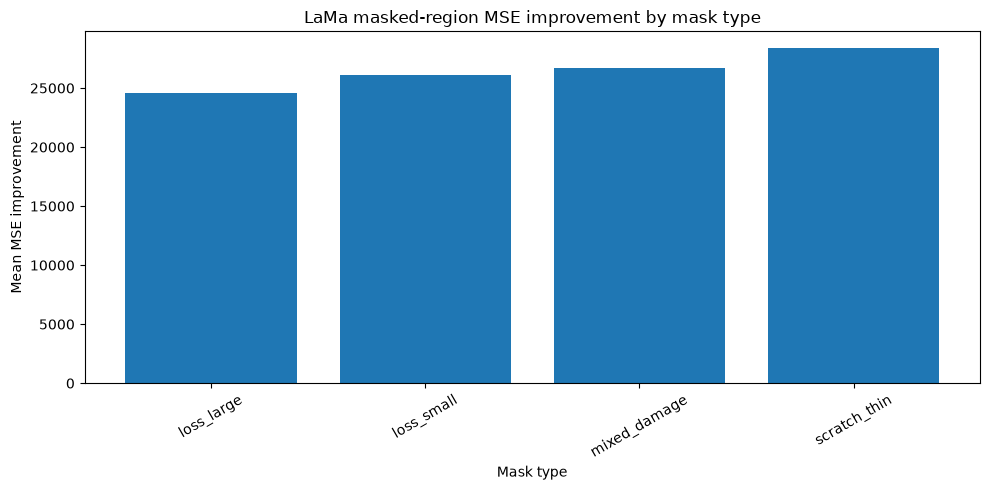

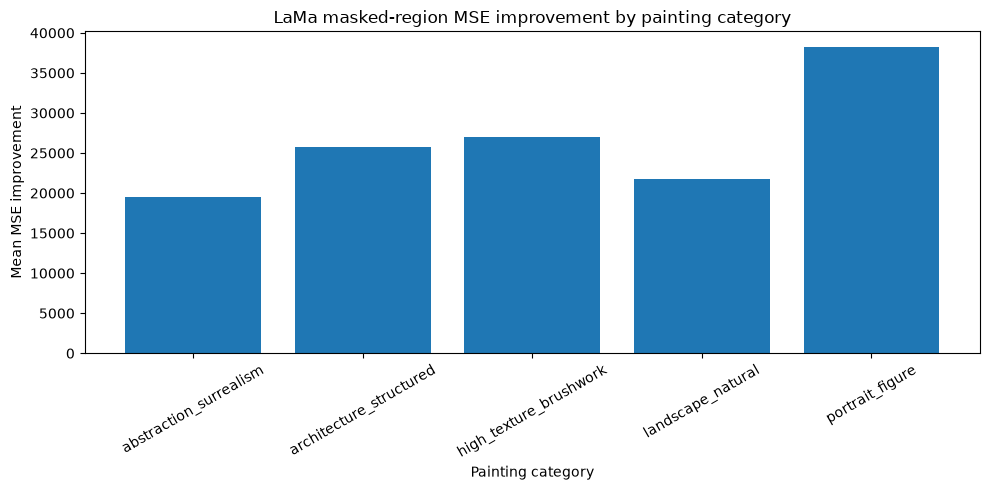

,category,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,abstraction_surrealism,40,40,20424.4236,940.1862,19484.2374,125.5444,16.4172,109.1272,5.8290,21.6331,15.8041,NaN,NaN,NaN,36481.850
1,architecture_structured,40,40,26114.8254,392.6224,25722.2030,152.8733,12.2894,140.5839,4.1508,22.9991,18.8484,NaN,NaN,NaN,32170.925
2,high_texture_brushwork,40,40,27422.5670,474.2475,26948.3196,158.0911,13.2929,144.7982,3.9737,22.9574,18.9837,NaN,NaN,NaN,34489.350
3,landscape_natural,40,40,22325.4391,559.3146,21766.1245,136.7356,14.2827,122.4529,5.3279,21.9957,16.6679,NaN,NaN,NaN,31748.150
4,portrait_figure,40,40,38691.4075,412.6760,38278.7315,190.5080,10.8114,179.6966,2.3711,24.7544,22.3834,NaN,NaN,NaN,32826.075


In [42]:
import matplotlib.pyplot as plt

plot_df = masked_region_summary_df.copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df["mask_type"], plot_df["mean_mse_improvement"])
ax.set_title("LaMa masked-region MSE improvement by mask type")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean MSE improvement")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

category_masked_summary_df = summarize_classical_metrics(
    masked_region_metrics_df,
    group_columns=["category"],
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(category_masked_summary_df["category"], category_masked_summary_df["mean_mse_improvement"])
ax.set_title("LaMa masked-region MSE improvement by painting category")
ax.set_xlabel("Painting category")
ax.set_ylabel("Mean MSE improvement")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

display(category_masked_summary_df)

In [43]:
# Select metric-driven visual cases after classical metrics.
# These are not final quality rankings; they are diagnostic examples
# tied to masked-region MSE improvement.

metric_visual_case_ids = []

# 1. Top 3 strongest masked-region MSE improvement cases.
metric_visual_case_ids.extend(
    strongest_masked_region_cases_df["case_id"].head(3).tolist()
)

# 2. Top 3 weakest masked-region MSE improvement cases.
metric_visual_case_ids.extend(
    weakest_masked_region_cases_df["case_id"].head(3).tolist()
)

# 3. One loss_large case per category, selected by median-ish MSE improvement.
loss_large_masked_df = masked_region_metrics_df[
    masked_region_metrics_df["mask_type"] == "loss_large"
].copy()

for category in sorted(loss_large_masked_df["category"].dropna().unique()):
    category_df = (
        loss_large_masked_df[loss_large_masked_df["category"] == category]
        .copy()
        .sort_values("mse_improvement")
        .reset_index(drop=True)
    )

    if len(category_df) > 0:
        median_index = len(category_df) // 2
        metric_visual_case_ids.append(category_df.loc[median_index, "case_id"])

# De-duplicate while preserving order.
metric_visual_case_ids = list(dict.fromkeys(metric_visual_case_ids))

lama_metric_visual_df = (
    lama_restored_df[lama_restored_df["case_id"].isin(metric_visual_case_ids)]
    .copy()
)

# Attach category if missing.
if "category" not in lama_metric_visual_df.columns or lama_metric_visual_df["category"].isna().all():
    category_lookup_df = (
        processed_clean_df[["painting_id", "category"]]
        .drop_duplicates()
        .copy()
    )

    lama_metric_visual_df = lama_metric_visual_df.drop(
        columns=["category"],
        errors="ignore",
    )

    lama_metric_visual_df = lama_metric_visual_df.merge(
        category_lookup_df,
        on="painting_id",
        how="left",
    )

# Attach metric values for display.
metric_columns_for_visuals = [
    "case_id",
    "evaluation_region",
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
]

masked_metric_lookup_df = masked_region_metrics_df[
    metric_columns_for_visuals
].copy()

lama_metric_visual_df = lama_metric_visual_df.merge(
    masked_metric_lookup_df,
    on="case_id",
    how="left",
)

# Restore selected order.
lama_metric_visual_df = (
    lama_metric_visual_df
    .set_index("case_id")
    .loc[metric_visual_case_ids]
    .reset_index()
)

print("Selected metric-driven LaMa visual cases:", len(lama_metric_visual_df))

display(
    lama_metric_visual_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_mae",
            "restored_mae",
            "mae_improvement",
            "restored_path",
        ]
    ]
)

Selected metric-driven LaMa visual cases: 11


,case_id,painting_id,category,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_mae,restored_mae,mae_improvement,restored_path
0,p006_loss_large,p006,portrait_figure,loss_large,52182.812500,143.131882,52039.680618,227.927612,6.756586,221.171026,data/processed/restored/lama/p006_loss_large_r...
1,p006_mixed_damage,p006,portrait_figure,mixed_damage,51966.468750,28.328691,51938.140059,227.115173,3.134551,223.980622,data/processed/restored/lama/p006_mixed_damage...
2,p002_loss_large,p002,portrait_figure,loss_large,51229.851562,94.772537,51135.079025,225.618668,6.456553,219.162114,data/processed/restored/lama/p002_loss_large_r...
3,p036_loss_large,p036,abstraction_surrealism,loss_large,5263.032715,3578.788330,1684.244385,46.358219,22.574953,23.783266,data/processed/restored/lama/p036_loss_large_r...
4,p036_scratch_thin,p036,abstraction_surrealism,scratch_thin,2009.945190,23.089705,1986.855486,29.343353,2.382572,26.960781,data/processed/restored/lama/p036_scratch_thin...
5,p032_mixed_damage,p032,abstraction_surrealism,mixed_damage,2763.684326,29.557987,2734.126339,40.720081,3.702726,37.017356,data/processed/restored/lama/p032_mixed_damage...
6,p033_loss_large,p033,abstraction_surrealism,loss_large,26186.804688,4599.542480,21587.262207,145.011688,46.184540,98.827148,data/processed/restored/lama/p033_loss_large_r...
7,p027_loss_large,p027,architecture_structured,loss_large,27120.300781,772.590210,26347.710571,157.130310,20.103289,137.027021,data/processed/restored/lama/p027_loss_large_r...
8,p045_loss_large,p045,high_texture_brushwork,loss_large,26202.400391,1484.510498,24717.889893,156.994385,26.169533,130.824852,data/processed/restored/lama/p045_loss_large_r...
9,p018_loss_large,p018,landscape_natural,loss_large,21350.681641,1066.452148,20284.229492,136.698166,16.825075,119.873091,data/processed/restored/lama/p018_loss_large_r...


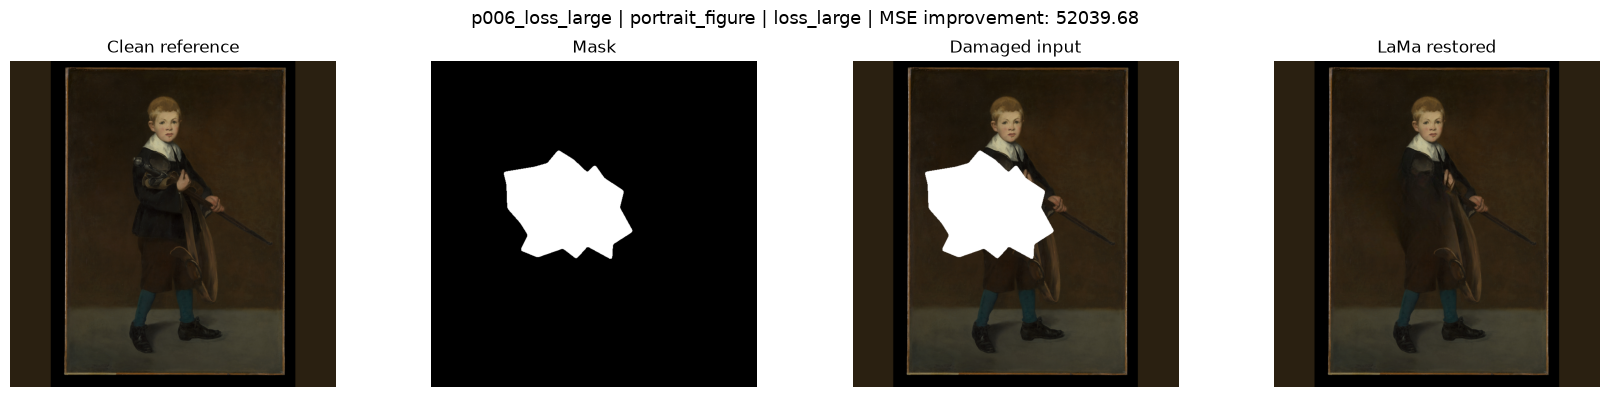

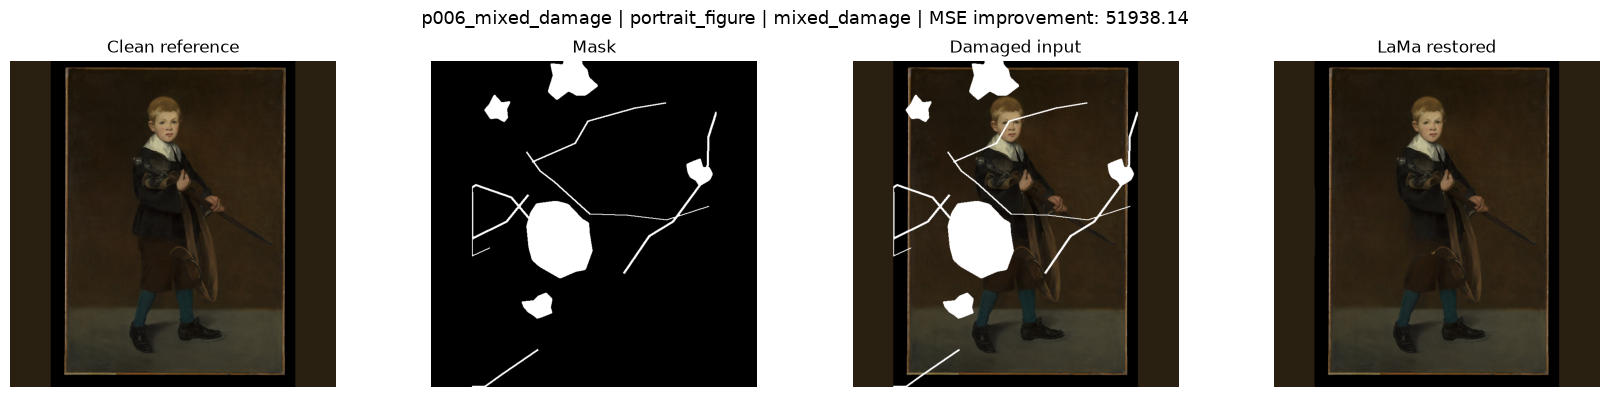

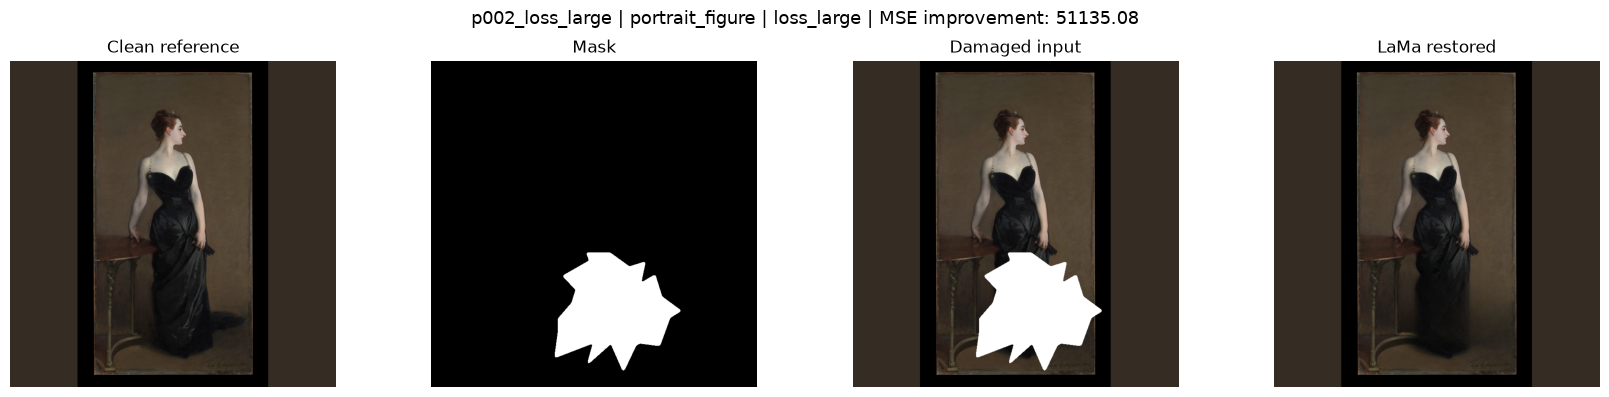

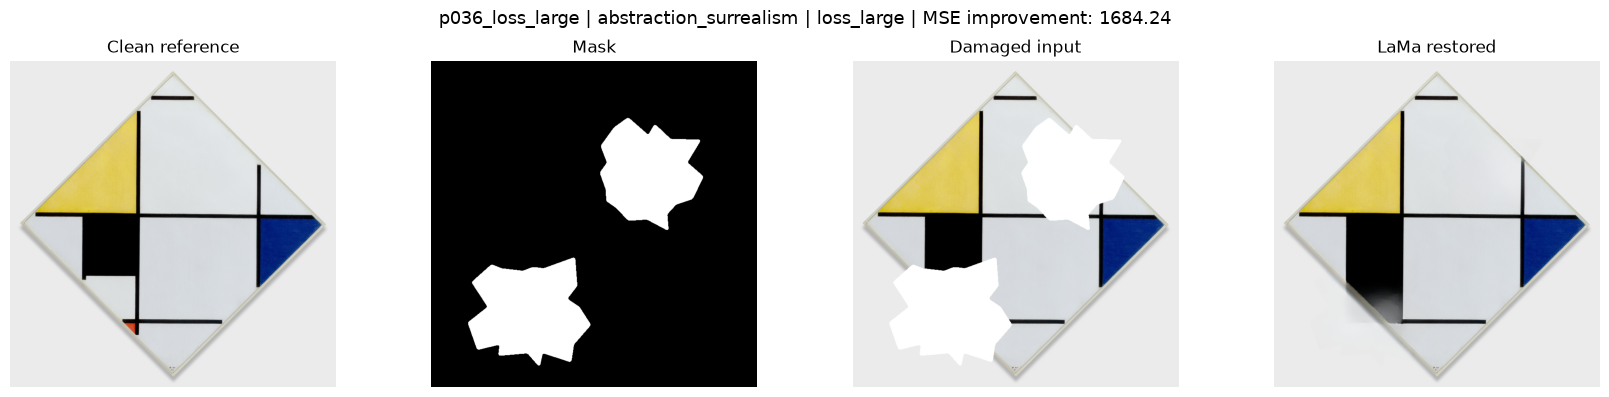

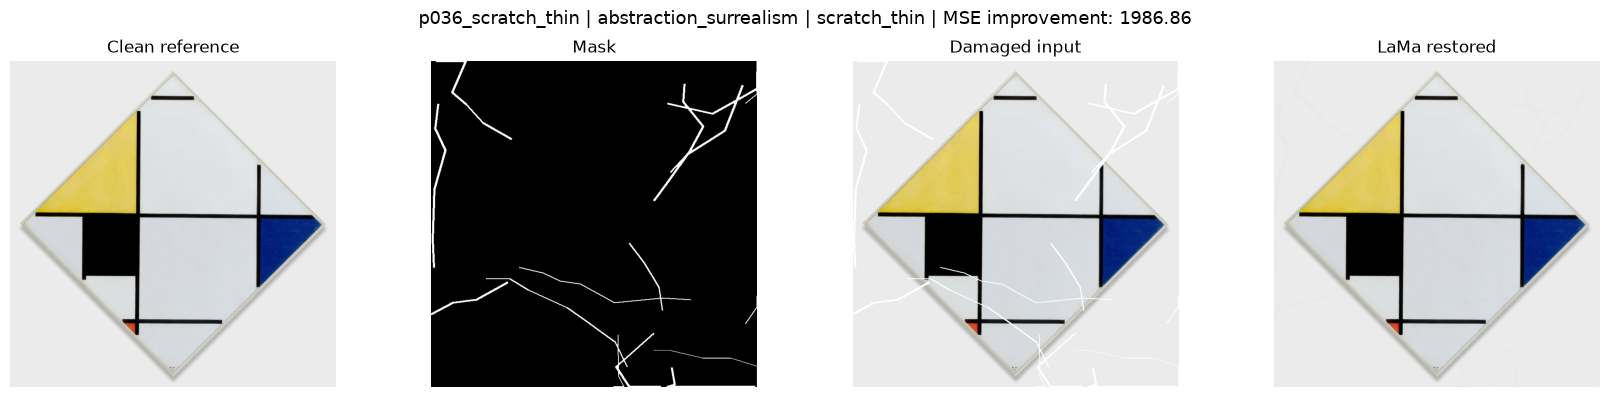

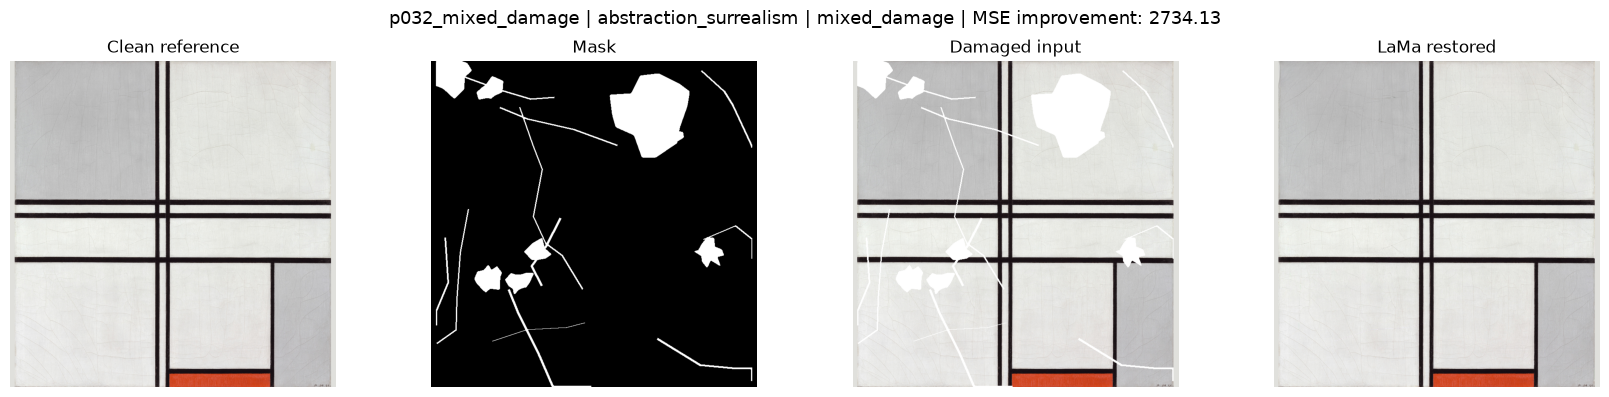

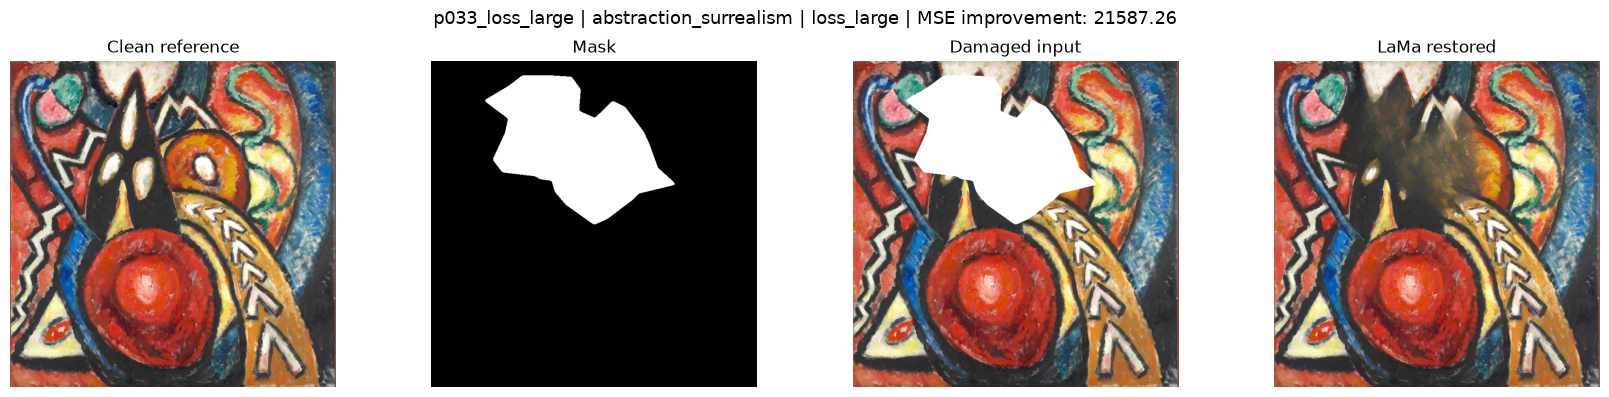

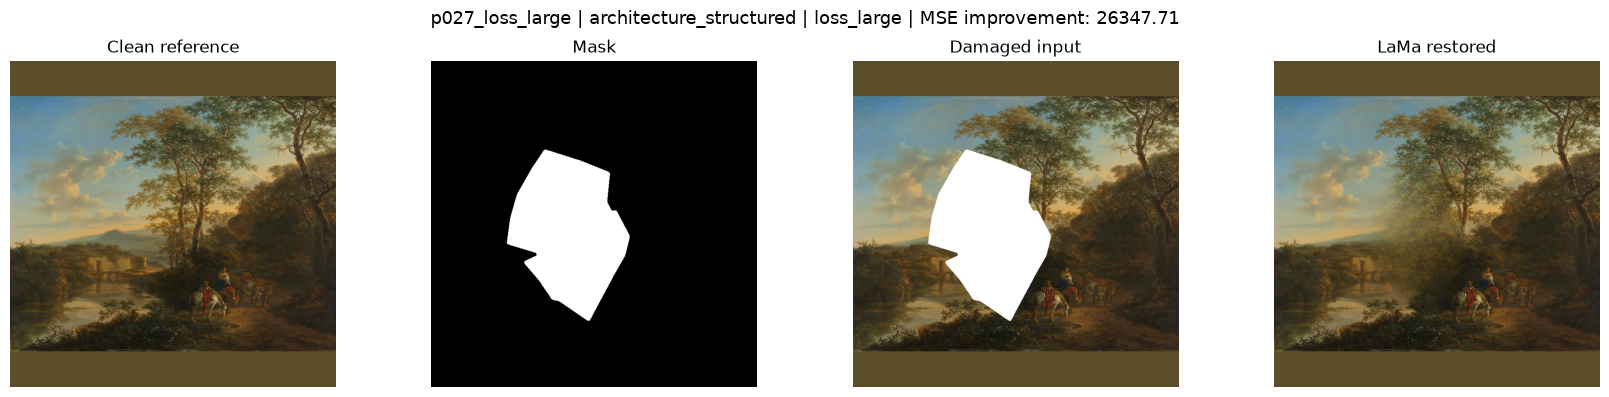

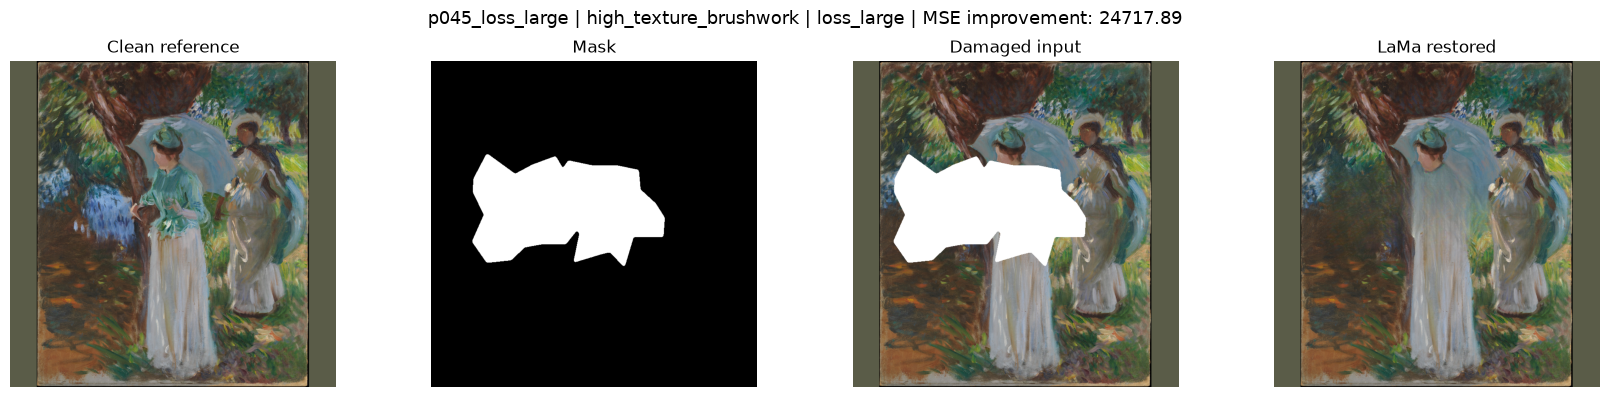

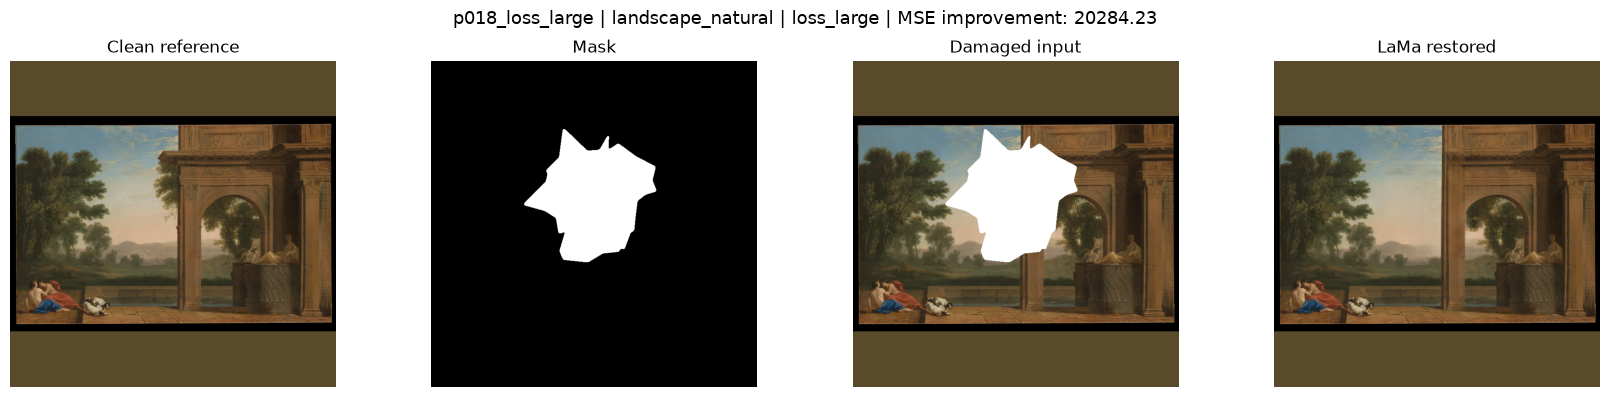

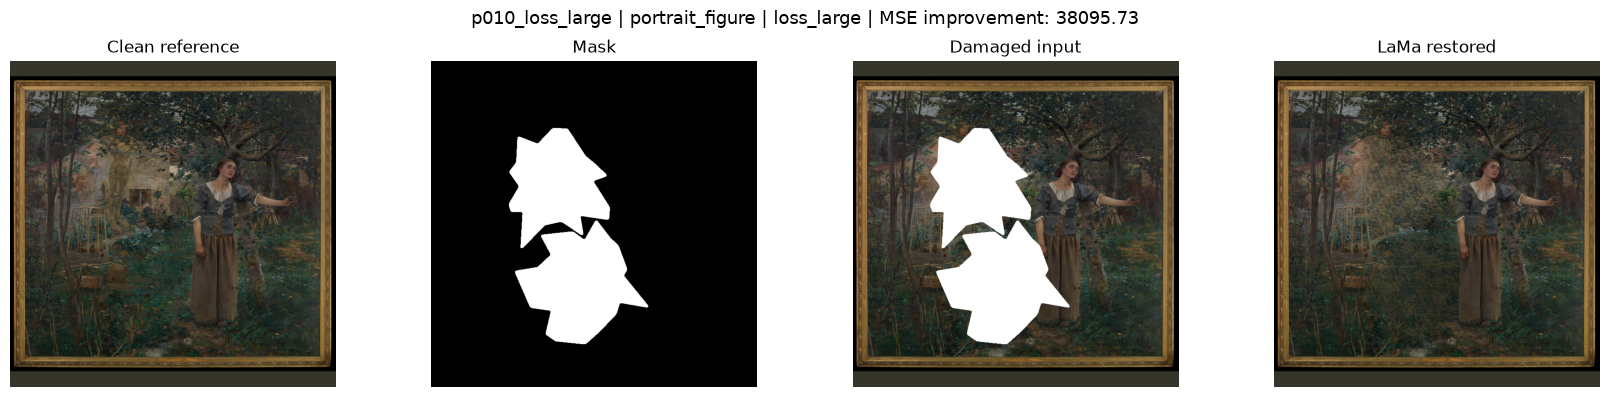

Saved LaMa classical metric visual case manifest:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lama_classical_metric_visual_cases_manifest_50.csv


,case_id,painting_id,category,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_mae,restored_mae,mae_improvement,figure_path
0,p006_loss_large,p006,portrait_figure,loss_large,52182.812500,143.131882,52039.680618,227.927612,6.756586,221.171026,outputs/figures/lama_classical_metric_cases/p0...
1,p006_mixed_damage,p006,portrait_figure,mixed_damage,51966.468750,28.328691,51938.140059,227.115173,3.134551,223.980622,outputs/figures/lama_classical_metric_cases/p0...
2,p002_loss_large,p002,portrait_figure,loss_large,51229.851562,94.772537,51135.079025,225.618668,6.456553,219.162114,outputs/figures/lama_classical_metric_cases/p0...
3,p036_loss_large,p036,abstraction_surrealism,loss_large,5263.032715,3578.788330,1684.244385,46.358219,22.574953,23.783266,outputs/figures/lama_classical_metric_cases/p0...
4,p036_scratch_thin,p036,abstraction_surrealism,scratch_thin,2009.945190,23.089705,1986.855486,29.343353,2.382572,26.960781,outputs/figures/lama_classical_metric_cases/p0...
5,p032_mixed_damage,p032,abstraction_surrealism,mixed_damage,2763.684326,29.557987,2734.126339,40.720081,3.702726,37.017356,outputs/figures/lama_classical_metric_cases/p0...
6,p033_loss_large,p033,abstraction_surrealism,loss_large,26186.804688,4599.542480,21587.262207,145.011688,46.184540,98.827148,outputs/figures/lama_classical_metric_cases/p0...
7,p027_loss_large,p027,architecture_structured,loss_large,27120.300781,772.590210,26347.710571,157.130310,20.103289,137.027021,outputs/figures/lama_classical_metric_cases/p0...
8,p045_loss_large,p045,high_texture_brushwork,loss_large,26202.400391,1484.510498,24717.889893,156.994385,26.169533,130.824852,outputs/figures/lama_classical_metric_cases/p0...
9,p018_loss_large,p018,landscape_natural,loss_large,21350.681641,1066.452148,20284.229492,136.698166,16.825075,119.873091,outputs/figures/lama_classical_metric_cases/p0...


In [44]:
from PIL import Image

metric_lama_figures_dir = PROJECT_ROOT / "outputs" / "figures" / "lama_classical_metric_cases"
metric_lama_figures_dir.mkdir(parents=True, exist_ok=True)

metric_visual_manifest_rows = []

for _, row in lama_metric_visual_df.iterrows():
    case_id = row["case_id"]
    painting_id = row["painting_id"]
    category = row["category"]
    mask_type = row["mask_type"]

    clean_path = PROJECT_ROOT / row["clean_path"]
    damaged_path = PROJECT_ROOT / row["damaged_path"]
    mask_path = PROJECT_ROOT / row["mask_path"]
    restored_path = PROJECT_ROOT / row["restored_path"]

    clean_img = Image.open(clean_path).convert("RGB")
    damaged_img = Image.open(damaged_path).convert("RGB")
    mask_img = Image.open(mask_path).convert("L")
    restored_img = Image.open(restored_path).convert("RGB")

    fig, axes = plt.subplots(1, 4, figsize=(17, 4))

    axes[0].imshow(clean_img)
    axes[0].set_title("Clean reference")

    axes[1].imshow(mask_img, cmap="gray")
    axes[1].set_title("Mask")

    axes[2].imshow(damaged_img)
    axes[2].set_title("Damaged input")

    axes[3].imshow(restored_img)
    axes[3].set_title("LaMa restored")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        (
            f"{case_id} | {category} | {mask_type} | "
            f"MSE improvement: {row['mse_improvement']:.2f}"
        ),
        fontsize=13,
    )

    plt.tight_layout()

    figure_path = metric_lama_figures_dir / f"{case_id}_lama_classical_metric_case.png"
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    metric_visual_manifest_rows.append(
        {
            "case_id": case_id,
            "painting_id": painting_id,
            "category": category,
            "mask_type": mask_type,
            "damaged_mse": row["damaged_mse"],
            "restored_mse": row["restored_mse"],
            "mse_improvement": row["mse_improvement"],
            "damaged_mae": row["damaged_mae"],
            "restored_mae": row["restored_mae"],
            "mae_improvement": row["mae_improvement"],
            "figure_path": figure_path.relative_to(PROJECT_ROOT).as_posix(),
        }
    )

lama_metric_visual_manifest_df = pd.DataFrame(metric_visual_manifest_rows)

lama_metric_visual_manifest_path = (
    metrics_dir / "lama_classical_metric_visual_cases_manifest_50.csv"
)

lama_metric_visual_manifest_df.to_csv(
    lama_metric_visual_manifest_path,
    index=False,
)

print("Saved LaMa classical metric visual case manifest:")
print(lama_metric_visual_manifest_path)

display(lama_metric_visual_manifest_df)

In [45]:
expected_output_paths = [
    classical_metrics_path,
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    masked_region_summary_path,
    strongest_cases_path,
    weakest_cases_path,
    lama_metric_visual_manifest_path,
]

for output_path in expected_output_paths:
    if not output_path.exists():
        raise FileNotFoundError(f"Missing expected output: {output_path}")

saved_classical_df = pd.read_csv(classical_metrics_path)

if len(saved_classical_df) != 900:
    raise ValueError(
        f"Expected 900 saved classical metric rows, found {len(saved_classical_df)}."
    )

if (saved_classical_df["status"] != "ok").any():
    display(saved_classical_df[saved_classical_df["status"] != "ok"])
    raise ValueError("Saved classical metrics contain non-ok rows.")

region_counts = saved_classical_df["evaluation_region"].value_counts().to_dict()
expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "masked_region": 200,
    "mask_bbox_crop": 200,
}

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = region_counts.get(region, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Region {region!r}: expected {expected_count}, found {actual_count}."
        )

category_counts = saved_classical_df["category"].value_counts(dropna=False).to_dict()
expected_category_counts = {
    "portrait_figure": 180,
    "landscape_natural": 180,
    "architecture_structured": 180,
    "abstraction_surrealism": 180,
    "high_texture_brushwork": 180,
}

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

if "" in category_counts or saved_classical_df["category"].isna().any():
    raise ValueError("Saved classical metrics still contain blank or missing category labels.")

if not metric_lama_figures_dir.exists():
    raise FileNotFoundError(
        f"Missing expected figure directory: {metric_lama_figures_dir}"
    )

metric_figure_paths = list(metric_lama_figures_dir.glob("*.png"))

print("\nMetric-driven visual figure count:", len(metric_figure_paths))

if len(metric_figure_paths) == 0:
    raise FileNotFoundError(
        f"No metric-driven LaMa visual figures found in: {metric_lama_figures_dir}"
    )

saved_visual_manifest_df = pd.read_csv(lama_metric_visual_manifest_path)

if len(saved_visual_manifest_df) == 0:
    raise ValueError("LaMa metric visual manifest is empty.")

missing_visual_figures = []

for _, row in saved_visual_manifest_df.iterrows():
    figure_path = PROJECT_ROOT / row["figure_path"]
    if not figure_path.exists():
        missing_visual_figures.append(row["figure_path"])

if missing_visual_figures:
    raise FileNotFoundError(
        f"Missing visual figure files listed in manifest: {missing_visual_figures[:10]}"
    )

print("\nFinal LaMa classical metric output gates passed.")

Expected region counts: {'full_image': 250, 'content_region': 250, 'masked_region': 200, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'masked_region': 200, 'mask_bbox_crop': 200}

Expected category counts: {'portrait_figure': 180, 'landscape_natural': 180, 'architecture_structured': 180, 'abstraction_surrealism': 180, 'high_texture_brushwork': 180}
Actual category counts: {'portrait_figure': 180, 'landscape_natural': 180, 'architecture_structured': 180, 'abstraction_surrealism': 180, 'high_texture_brushwork': 180}

Metric-driven visual figure count: 11

Final LaMa classical metric output gates passed.


## LaMa classical metric summary

This notebook computed classical full-reference metrics for the LaMa pretrained inpainting baseline on the controlled 50-painting subset.

The evaluation compares:

- clean reference vs damaged input,
- clean reference vs LaMa restored output.

The computed metrics are:

- MSE,
- MAE,
- PSNR,
- SSIM.

The evaluation regions match the OpenCV Telea baseline:

- full image,
- content region,
- masked region,
- mask bounding-box crop.

The final metric output contains 900 rows:

- 250 full-image rows,
- 250 content-region rows,
- 200 masked-region rows,
- 200 mask-bounding-box crop rows.

Zero-control cases are included for full-image and content-region checks, but they are excluded from masked-region and mask-bounding-box crop rows because they contain no damaged pixels.

The main output file is:

`outputs/metrics/classical_metrics_lama_50.csv`

Additional summaries were saved by:

- mask type,
- painting category,
- evaluation region,
- evaluation region and mask type,
- masked-region mask type.

The strongest and weakest LaMa cases were ranked by absolute masked-region MSE improvement. These rankings should be interpreted carefully: a large MSE improvement means the restored pixels became numerically closer to the clean reference, but it does not by itself prove perceptual or historically faithful restoration quality.

This notebook prepares the LaMa classical metric baseline. Later notebooks will add LaMa error maps, LPIPS, CLIP/DINOv2 feature-space similarity, and direct OpenCV-vs-LaMa comparison.